<a href="https://colab.research.google.com/github/Nyfeu/Data-Science/blob/main/ex_matplotlib1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<head>
  <meta name="author" content="Rogério de Oliveira">
  <meta institution="author" content="ITM">
</head>

<img src="https://maua.br/images/selo-60-anos-maua.svg" width=300, align="right">
<!-- <h1 align=left><font size = 6, style="color:rgb(200,0,0)"> optional title </font></h1> -->

# Lab: Matplotlib

O principal objetivo desse lab é você entender como funciona a construção em camadas do `Matplotlib`, e como empregar os modos `script layer` e `artist layer` para produzir múltiplos gráficos em uma figura.

<br>

<img src="https://github.com/Rogerio-mack/Visualizacao-de-Dados-em-Python/raw/main/figuras/capas/1.png" width="20%"/>

Oliveira, R. (2022). [Visualizacao de Dados em Python](https://github.com/Rogerio-mack/Visualizacao-de-Dados-em-Python) Cap. 3






# Basic imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns


# Exercício 1 `plt.plot()`, function. (**RESOLVIDO**)

Produza um gráfico de linha da função $tanh(x)$ para $x \in [-10,10]$.

1. Inclua um título com a função
2. Altere a cor e o estilo de linha do gráfico
3. Altere o tamanho da figura
4. Inclua rótulos para os eixos do gráfico

In [2]:
def f(x):
  return np.tanh(x)

x = np.arange(-10.0,10.0,0.05)
y = f(x)

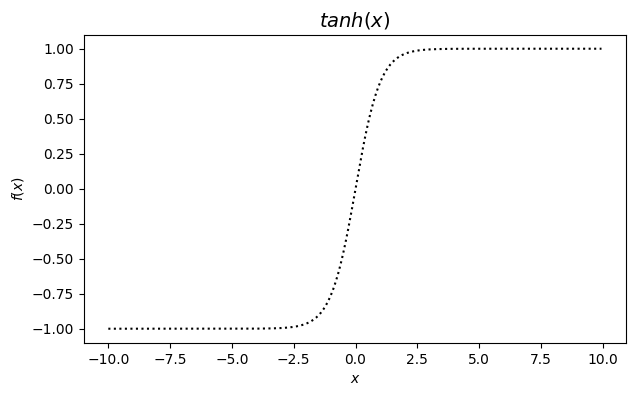

In [3]:
plt.figure(figsize=(7,4))

plt.plot(x, y, color='k', linestyle=':')
# plt.plot(x, y, 'k:')
plt.title('$tanh(x)$',fontsize=14)
plt.xlabel('$x$')
plt.ylabel('$f(x)$')
plt.show()

# Exercício 2 `plt.plot()`, random data. (**RESOLVIDO**)

Produza um gráfico a partir do dataframe abaixo.

1. Inclua um título
2. Altere a cor e o estilo de linha do gráfico
3. Altere o tamanho da figura
4. Inclua rótulos para os eixos do gráfico

In [4]:
df = pd.DataFrame()
df['x-values'] = np.arange(0,10,0.01)
df['y-values'] = np.random.sample(len(df))
df.head()


,x-values,y-values
0,0.00,0.772108
1,0.01,0.953003
2,0.02,0.197884
3,0.03,0.521064
4,0.04,0.627049


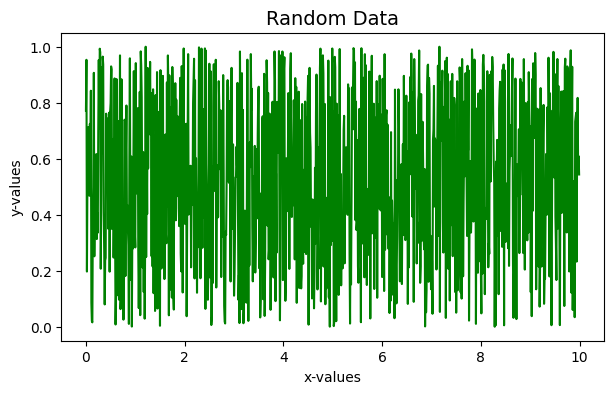

In [5]:
plt.figure(figsize=(7,4))

plt.plot('x-values', 'y-values', data=df, color='g', linestyle='-')
# plt.plot(df['x-values'], df['y-values'], color='g', linestyle='-')
plt.title('Random Data',fontsize=14)
plt.xlabel('x-values')
plt.ylabel('y-values')
plt.show()

# **CASE: fmri**

Nos exercícios a seguir partimos da seguinte base de dados:

In [6]:
df = sns.load_dataset('fmri')
df.head()

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970


# Pré Exercício!

Explore a base antes de prosseguir. **Ordene os dados no tempo** antes de seguir.

Dica: `df.sort_values()`

In [17]:
df = df.sort_values('timepoint')
df.head()

,subject,timepoint,event,region,signal
270,s4,0,stim,frontal,-0.017516
968,s4,0,cue,frontal,-0.039116
706,s1,0,cue,parietal,-0.057706
284,s1,0,stim,frontal,-0.046049
703,s4,0,cue,parietal,-0.045956


In [8]:
#@markdown This cell is configured to not execute. **Do not change this**.
%%script echo skipping
df = df.sort_values('timepoint')
df.head()

np.random.seed(1)
r = np.random.randint(0,len(df.subject.unique())+1,len(df.subject.unique()))
s = np.sort( df.subject.unique() )
r = s[r]

for i in range(len(s)):
  df.subject = df.subject.replace(r[i],'x')
  df.subject = df.subject.replace(s[i],r[i])
  df.subject = df.subject.replace('x',s[i])

df.to_csv('fmri.csv',index=None)

df = pd.read_csv('fmri.csv')
# df.head()


skipping


# Q1.

Produza um gráfico como abaixo para o sujeito `s0`. Observe todos os elementos do gráfico como a seleção dos dados (sujeito `s0`, região `parietal` e evento de `stim`), títulos e rótulos.

![imagem](https://github.com/Rogerio-mack/IMT_Ciencia_de_Dados/raw/main/images/ex_matplotlib1_3.png)

**Para o sujeito s0, os valores de sinal encontram-se melhor em que intervalo de valores?**





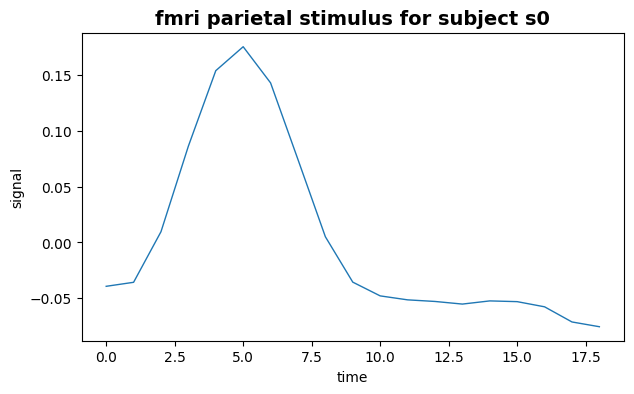

Os valores de sinal para o sujeito s0 variam de -0.0756 a 0.1755.


In [25]:
# Filtrando os dados para sujeito s0, região parietal e evento stim
df_s0 = df[(df['subject'] == 's0') & (df['region'] == 'parietal') & (df['event'] == 'stim')]

# Criando o gráfico
plt.figure(figsize=(7, 4))
plt.plot(df_s0['timepoint'], df_s0['signal'], label='s0', color='tab:blue', linewidth=1.0)

# Adicionando títulos e rótulos
plt.title('fmri parietal stimulus for subject s0', fontsize=14, fontweight='bold')
plt.xlabel('time')
plt.ylabel('signal')
# Legenda removida a pedido do usuário
plt.show()

# Respondendo à pergunta sobre o intervalo de valores
min_signal = df_s0['signal'].min()
max_signal = df_s0['signal'].max()
print(f'Os valores de sinal para o sujeito s0 variam de {min_signal:.4f} a {max_signal:.4f}.')

# Q2.

Produza um gráfico como abaixo para o sujeito `s0`. Observe todos os elementos do gráfico como a seleção dos dados (sujeito `s0`, região `parietal` e eventos de `stim` e `cue`), títulos e rótulos.

![imagem](https://github.com/Rogerio-mack/IMT_Ciencia_de_Dados/raw/main/images/ex_matplotlib1_4.png)


**Para o sujeito s0, os valores de repouso (cue) apresentam uma variação menor que a dos estímulos?**

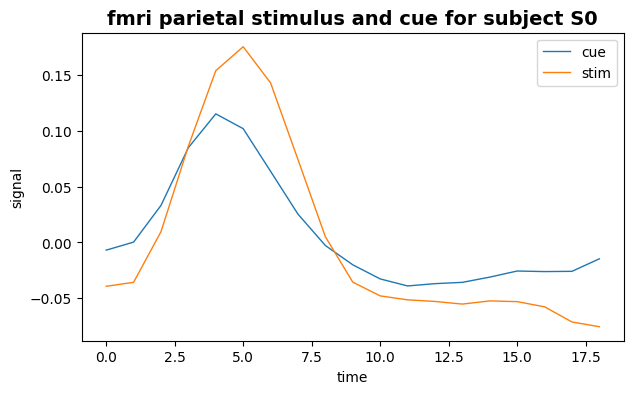

Variação (amplitude) de cue: 0.1543
Variação (amplitude) de stim: 0.2511
Resposta: Sim, os valores de repouso (cue) apresentam uma variação menor que a dos estímulos.


In [26]:
# Filtrando os dados para sujeito s0, região parietal, eventos stim e cue
df_s0_stim = df[(df['subject'] == 's0') & (df['region'] == 'parietal') & (df['event'] == 'stim')]
df_s0_cue = df[(df['subject'] == 's0') & (df['region'] == 'parietal') & (df['event'] == 'cue')]

# Criando o gráfico
plt.figure(figsize=(7, 4))
plt.plot(df_s0_cue['timepoint'], df_s0_cue['signal'], label='cue', color='tab:blue', linewidth=1.0)
plt.plot(df_s0_stim['timepoint'], df_s0_stim['signal'], label='stim', color='tab:orange', linewidth=1.0)

# Adicionando títulos e rótulos
plt.title('fmri parietal stimulus and cue for subject S0', fontsize=14, fontweight='bold')
plt.xlabel('time')
plt.ylabel('signal')
plt.legend(loc='upper right')
plt.show()

# Calculando a amplitude de variação (máximo - mínimo)
var_cue = df_s0_cue['signal'].max() - df_s0_cue['signal'].min()
var_stim = df_s0_stim['signal'].max() - df_s0_stim['signal'].min()

print(f'Variação (amplitude) de cue: {var_cue:.4f}')
print(f'Variação (amplitude) de stim: {var_stim:.4f}')

if var_cue < var_stim:
    print('Resposta: Sim, os valores de repouso (cue) apresentam uma variação menor que a dos estímulos.')
else:
    print('Resposta: Não, os valores de repouso (cue) apresentam uma variação maior ou igual a dos estímulos.')

# Q3. `plt.subplot(nrow, ncol, nr)`

Produza um gráfico como abaixo para os sujeitos `s0` e `s1`, em uma mesma figura empregando o modo `script layer`. Observe todos os demais elementos do gráfico.

![imagem](https://github.com/Rogerio-mack/IMT_Ciencia_de_Dados/raw/main/images/ex_matplotlib1_5.png)

**Para o sujeito s1, os sinais apresentam uma variação menor, aproximadamente igual ou maior com relação ao sujeito s0?**

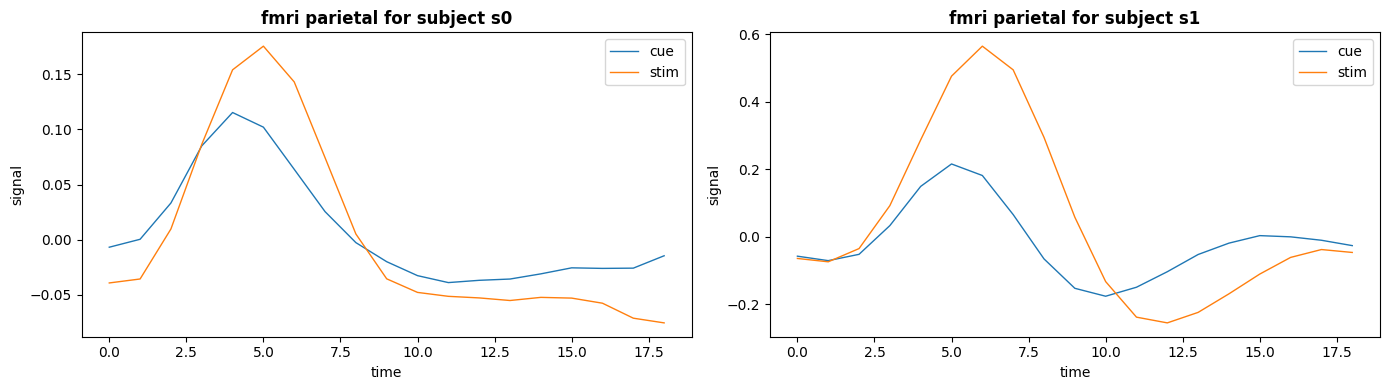

Variação (estim) s0: 0.2511
Variação (estim) s1: 0.8205
Resposta: Para o sujeito s1, os sinais apresentam uma variação maior com relação ao sujeito s0.


In [27]:
plt.figure(figsize=(14, 4))

# Subplot 1: Sujeito s0
plt.subplot(1, 2, 1)
df_s0_stim = df[(df['subject'] == 's0') & (df['region'] == 'parietal') & (df['event'] == 'stim')]
df_s0_cue = df[(df['subject'] == 's0') & (df['region'] == 'parietal') & (df['event'] == 'cue')]
plt.plot(df_s0_cue['timepoint'], df_s0_cue['signal'], label='cue', color='tab:blue', linewidth=1.0)
plt.plot(df_s0_stim['timepoint'], df_s0_stim['signal'], label='stim', color='tab:orange', linewidth=1.0)
plt.title('fmri parietal for subject s0', fontsize=12, fontweight='bold')
plt.xlabel('time')
plt.ylabel('signal')
plt.legend(loc='upper right')

# Subplot 2: Sujeito s1
plt.subplot(1, 2, 2)
df_s1_stim = df[(df['subject'] == 's1') & (df['region'] == 'parietal') & (df['event'] == 'stim')]
df_s1_cue = df[(df['subject'] == 's1') & (df['region'] == 'parietal') & (df['event'] == 'cue')]
plt.plot(df_s1_cue['timepoint'], df_s1_cue['signal'], label='cue', color='tab:blue', linewidth=1.0)
plt.plot(df_s1_stim['timepoint'], df_s1_stim['signal'], label='stim', color='tab:orange', linewidth=1.0)
plt.title('fmri parietal for subject s1', fontsize=12, fontweight='bold')
plt.xlabel('time')
plt.ylabel('signal')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Comparativo de variação
var_s0 = df_s0_stim['signal'].max() - df_s0_stim['signal'].min()
var_s1 = df_s1_stim['signal'].max() - df_s1_stim['signal'].min()

print(f'Variação (estim) s0: {var_s0:.4f}')
print(f'Variação (estim) s1: {var_s1:.4f}')

if abs(var_s1 - var_s0) < 0.01:
    print("Resposta: Para o sujeito s1, os sinais apresentam uma variação aproximadamente igual com relação ao sujeito s0.")
elif var_s1 > var_s0:
    print("Resposta: Para o sujeito s1, os sinais apresentam uma variação maior com relação ao sujeito s0.")
else:
    print("Resposta: Para o sujeito s1, os sinais apresentam uma variação menor com relação ao sujeito s0.")

# Q4. `plt.subplots(nrow,ncol,...)` `ax[i,<j>]`

Produza um gráfico como abaixo para os sujeitos `s0` e `s1`, em uma mesma figura empregando, agora empregando o modo `artist layer`. Observe todos os demais elementos do gráfico.

![imagem](https://github.com/Rogerio-mack/IMT_Ciencia_de_Dados/raw/main/images/ex_matplotlib1_6.png)

**Qual a dimensão do ax criado? (dica: empregue ax.shape)**

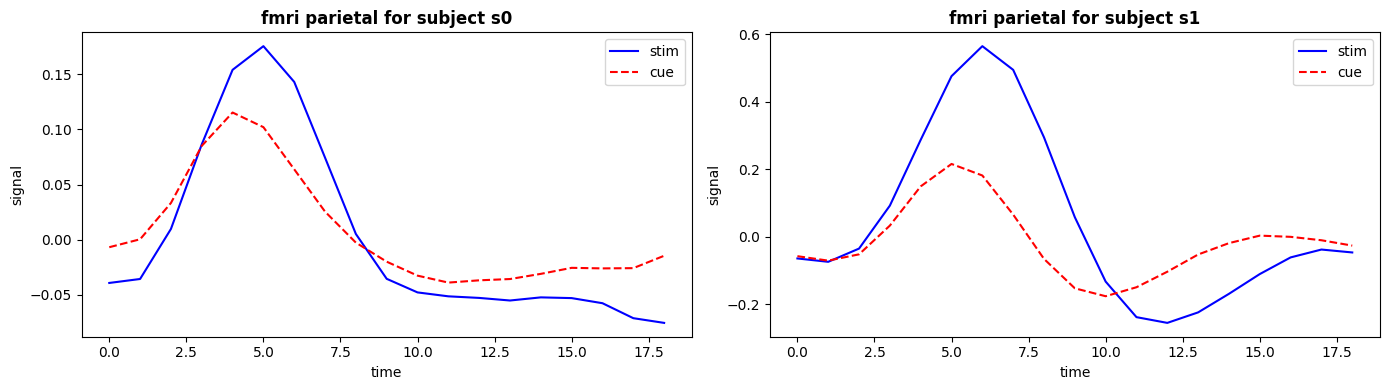

A dimensão do ax criado é: (2,)


In [28]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Dados Sujeito s0
df_s0_stim = df[(df['subject'] == 's0') & (df['region'] == 'parietal') & (df['event'] == 'stim')]
df_s0_cue = df[(df['subject'] == 's0') & (df['region'] == 'parietal') & (df['event'] == 'cue')]

ax[0].plot(df_s0_stim['timepoint'], df_s0_stim['signal'], color='blue', label='stim')
ax[0].plot(df_s0_cue['timepoint'], df_s0_cue['signal'], color='red', linestyle='--', label='cue')
ax[0].set_title('fmri parietal for subject s0', fontweight='bold')
ax[0].set_xlabel('time')
ax[0].set_ylabel('signal')
ax[0].legend()

# Dados Sujeito s1
df_s1_stim = df[(df['subject'] == 's1') & (df['region'] == 'parietal') & (df['event'] == 'stim')]
df_s1_cue = df[(df['subject'] == 's1') & (df['region'] == 'parietal') & (df['event'] == 'cue')]

ax[1].plot(df_s1_stim['timepoint'], df_s1_stim['signal'], color='blue', label='stim')
ax[1].plot(df_s1_cue['timepoint'], df_s1_cue['signal'], color='red', linestyle='--', label='cue')
ax[1].set_title('fmri parietal for subject s1', fontweight='bold')
ax[1].set_xlabel('time')
ax[1].set_ylabel('signal')
ax[1].legend()

plt.tight_layout()
plt.show()

print(f'A dimensão do ax criado é: {ax.shape}')

# Q5. `sharex, sharey`

Produza um gráfico como abaixo agora para os sujeitos `s0` a `s3`, em uma mesma figura empregando empregando o modo `artist layer`. Verifique no comando `subplots()` como compartilhar os eixos. Observe todos os demais elementos do gráfico.

![imagem](https://github.com/Rogerio-mack/IMT_Ciencia_de_Dados/raw/main/images/ex_matplotlib1_7.png)

**Quais sujeitos apresentam sinais mais intensos de estímulos?**

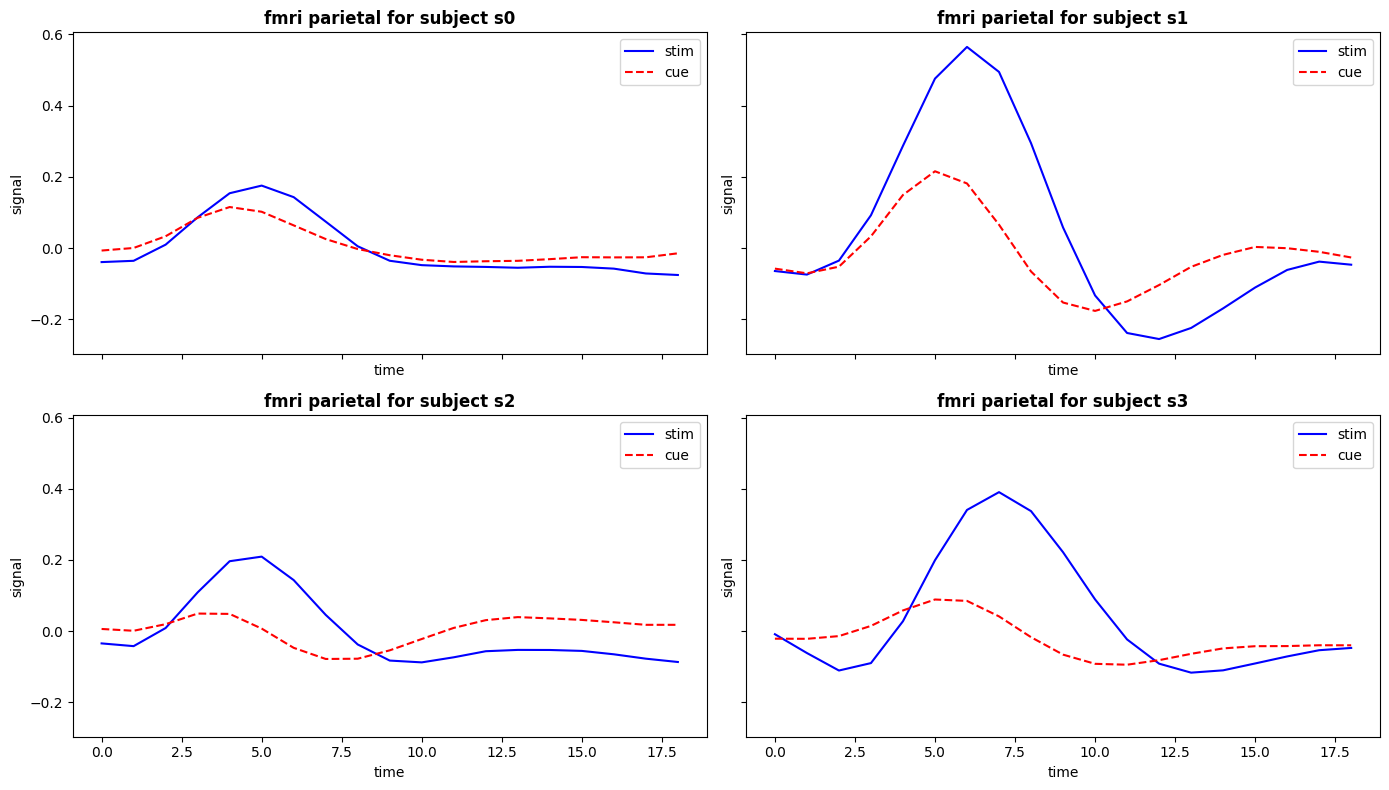

Picos de sinal (stim):
s0: 0.1755
s1: 0.5650
s2: 0.2094
s3: 0.3905

Resposta: Os sujeitos com sinais mais intensos de estímulos são s1 e s3.


In [29]:
import matplotlib.pyplot as plt

subjects = ['s0', 's1', 's2', 's3']
fig, ax = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
ax = ax.flatten()

max_signals = {}

for i, s in enumerate(subjects):
    df_stim = df[(df['subject'] == s) & (df['region'] == 'parietal') & (df['event'] == 'stim')]
    df_cue = df[(df['subject'] == s) & (df['region'] == 'parietal') & (df['event'] == 'cue')]

    ax[i].plot(df_stim['timepoint'], df_stim['signal'], color='blue', label='stim')
    ax[i].plot(df_cue['timepoint'], df_cue['signal'], color='red', linestyle='--', label='cue')

    ax[i].set_title(f'fmri parietal for subject {s}', fontweight='bold')
    ax[i].set_xlabel('time')
    ax[i].set_ylabel('signal')
    ax[i].legend()

    max_signals[s] = df_stim['signal'].max()

plt.tight_layout()
plt.show()

print('Picos de sinal (stim):')
for s, val in max_signals.items():
    print(f'{s}: {val:.4f}')

# Identificando sujeitos com sinais mais intensos
sorted_s = sorted(max_signals.items(), key=lambda x: x[1], reverse=True)
print(f'\nResposta: Os sujeitos com sinais mais intensos de estímulos são {sorted_s[0][0]} e {sorted_s[1][0]}.')